# 📈 모델 비교 실험: 로지스틱 회귀 vs 랜덤 포레스트 vs XGBoost

이 노트북은 `data/processed/selected_features_data.csv`를 활용하여 세 가지 다른 머신러닝 모델의 성능을 비교 분석합니다.

### 🧪 실험 설정
- **데이터 분할:** Train(70%) / Val(15%) / Test(15%) (시계열 순서 유지)
- **평가 지표:** Accuracy, Precision, Recall, F1-Score, ROC-AUC
- **모델:** Logistic Regression, Random Forest, XGBoost

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

## 1. 데이터 로드 및 시계열 분할 (70/15/15)

In [14]:
# 데이터 로드
DATA_PATH = "../data/processed/selected_features_data.csv"
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# 피처 및 타겟 분리
exclude = ['Date', 'ticker', 'target', 'next_return']
features = [c for c in df.columns if c not in exclude]
X = df[features]
y = df['target']

# 70 / 15 / 15 분할 인덱스 계산
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

print(f"Total samples: {n}")
print(f"Train samples: {len(X_train)} ({len(X_train)/n:.1%})")
print(f"Val samples: {len(X_val)} ({len(X_val)/n:.1%})")
print(f"Test samples: {len(X_test)} ({len(X_test)/n:.1%})")

Total samples: 1464
Train samples: 1024 (69.9%)
Val samples: 220 (15.0%)
Test samples: 220 (15.0%)


## 2. 모델 학습 및 평가 함수 정의

In [15]:
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, name):
    model.fit(X_train, y_train)
    
    sets = [('Train', X_train, y_train), ('Val', X_val, y_val), ('Test', X_test, y_test)]
    results = []
    
    print(f"\n=== {name} Performance ===")
    for set_name, X_set, y_set in sets:
        preds = model.predict(X_set)
        probs = model.predict_proba(X_set)[:, 1]
        
        acc = accuracy_score(y_set, preds)
        pre = precision_score(y_set, preds)
        rec = recall_score(y_set, preds)
        f1 = f1_score(y_set, preds)
        auc = roc_auc_score(y_set, probs)
        
        results.append({
            'Model': name,
            'Set': set_name,
            'Accuracy': acc,
            'Precision': pre,
            'Recall': rec,
            'F1': f1,
            'AUC': auc
        })
        print(f"[{set_name}] Acc: {acc:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    return results

In [16]:
# 3. 최적 파라미터 적용 및 학습

# 각 실험용 노트북에서 찾은 최적 파라미터를 적용합니다.

# Logistic Regression (Best: ElasticNet, C=0.053)
lr_model = LogisticRegression(
    C=0.05336699231206307, 
    class_weight=None, 
    l1_ratio=0.9, 
    penalty='elasticnet', 
    solver='saga', 
    max_iter=10000, 
    random_state=42
)

# Random Forest (Best: max_depth=5, min_samples_leaf=4)
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=5, 
    min_samples_leaf=4, 
    min_samples_split=10, 
    max_features='sqrt', 
    class_weight=None, 
    random_state=42
)

# XGBoost (Best: learning_rate=0.05, max_depth=5)
xgb_model = XGBClassifier(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=5, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    eval_metric='logloss', 
    random_state=42
)

all_results = []
all_results.extend(evaluate_model(lr_model, X_train, y_train, X_val, y_val, X_test, y_test, "Logistic Regression"))
all_results.extend(evaluate_model(rf_model, X_train, y_train, X_val, y_val, X_test, y_test, "Random Forest"))
all_results.extend(evaluate_model(xgb_model, X_train, y_train, X_val, y_val, X_test, y_test, "XGBoost"))


=== Logistic Regression Performance ===
[Train] Acc: 0.5469, F1: 0.6818, AUC: 0.5607
[Val] Acc: 0.5227, F1: 0.6828, AUC: 0.4859
[Test] Acc: 0.5227, F1: 0.6789, AUC: 0.5164

=== Random Forest Performance ===
[Train] Acc: 0.7607, F1: 0.8117, AUC: 0.9044
[Val] Acc: 0.5273, F1: 0.5630, AUC: 0.5183
[Test] Acc: 0.5227, F1: 0.5161, AUC: 0.4922

=== XGBoost Performance ===
[Train] Acc: 0.9951, F1: 0.9955, AUC: 1.0000
[Val] Acc: 0.4773, F1: 0.4550, AUC: 0.4867
[Test] Acc: 0.5136, F1: 0.5202, AUC: 0.4889


In [17]:
lr_model = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
xgb_model = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')

all_results = []
all_results.extend(evaluate_model(lr_model, X_train, y_train, X_val, y_val, X_test, y_test, "Logistic Regression"))
all_results.extend(evaluate_model(rf_model, X_train, y_train, X_val, y_val, X_test, y_test, "Random Forest"))
all_results.extend(evaluate_model(xgb_model, X_train, y_train, X_val, y_val, X_test, y_test, "XGBoost"))


=== Logistic Regression Performance ===
[Train] Acc: 0.5752, F1: 0.6567, AUC: 0.5956
[Val] Acc: 0.4909, F1: 0.4815, AUC: 0.4775
[Test] Acc: 0.4636, F1: 0.5280, AUC: 0.4643

=== Random Forest Performance ===
[Train] Acc: 1.0000, F1: 1.0000, AUC: 1.0000
[Val] Acc: 0.5273, F1: 0.5140, AUC: 0.5498
[Test] Acc: 0.4818, F1: 0.4571, AUC: 0.4790

=== XGBoost Performance ===
[Train] Acc: 1.0000, F1: 1.0000, AUC: 1.0000
[Val] Acc: 0.5273, F1: 0.5185, AUC: 0.5380
[Test] Acc: 0.4909, F1: 0.5214, AUC: 0.4925



--- [Final Test Set Comparison (Optimized Models)] ---


,Set,Accuracy,Precision,Recall,F1,AUC
Model,,,,,,
Logistic Regression,Test,0.463636,0.485294,0.578947,0.528000,0.464250
Random Forest,Test,0.481818,0.500000,0.421053,0.457143,0.479022
XGBoost,Test,0.490909,0.508333,0.535088,0.521368,0.492469


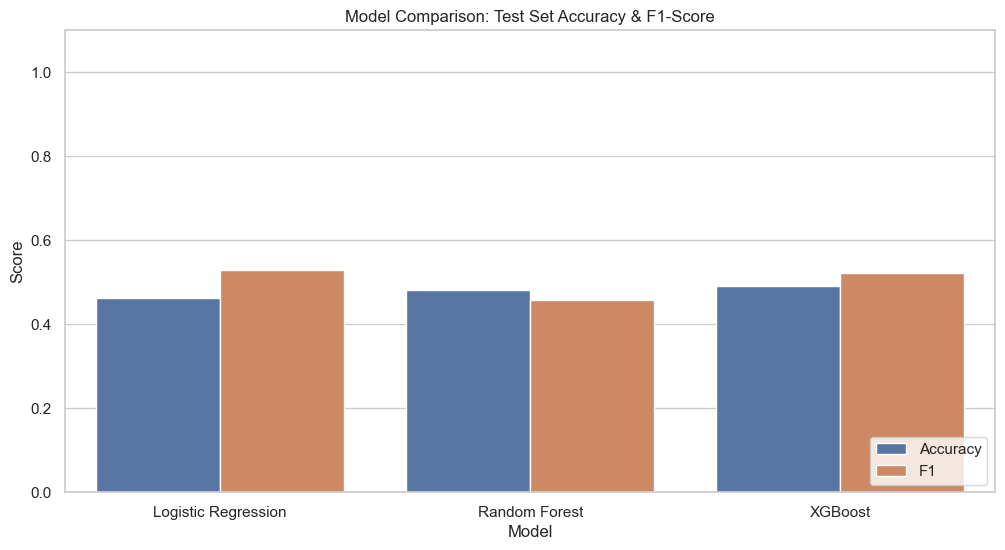

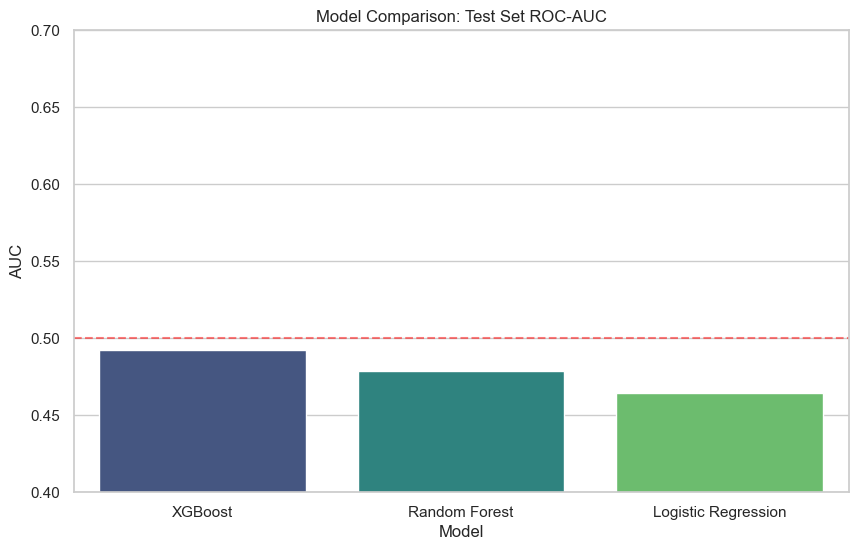

In [18]:
# 4. 최종 결과 비교 시각화

results_df = pd.DataFrame(all_results)

# Test Set 결과 비교 테이블
test_comparison = results_df[results_df['Set'] == 'Test'].set_index('Model')
print("\n--- [Final Test Set Comparison (Optimized Models)] ---")
display(test_comparison)

# 1. Accuracy vs F1 비교 (Test Set)
test_results = results_df[results_df['Set'] == 'Test']
melted_test = test_results.melt(id_vars='Model', value_vars=['Accuracy', 'F1'], var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=melted_test, x='Model', y='Score', hue='Metric')
plt.title("Model Comparison: Test Set Accuracy & F1-Score")
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.show()

# 2. ROC-AUC 비교 (Test Set)
plt.figure(figsize=(10, 6))
sns.barplot(data=test_results.sort_values('AUC', ascending=False), x='Model', y='AUC', palette='viridis')
plt.title("Model Comparison: Test Set ROC-AUC")
plt.ylim(0.4, 0.7) # 차이를 명확히 보기 위한 범위 조정
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5) # Baseline (Random)
plt.show()


--- [Final Test Set Comparison] ---


,Set,Accuracy,Precision,Recall,F1,AUC
Model,,,,,,
Logistic Regression,Test,0.463636,0.485294,0.578947,0.528000,0.464250
Random Forest,Test,0.481818,0.500000,0.421053,0.457143,0.479022
XGBoost,Test,0.490909,0.508333,0.535088,0.521368,0.492469


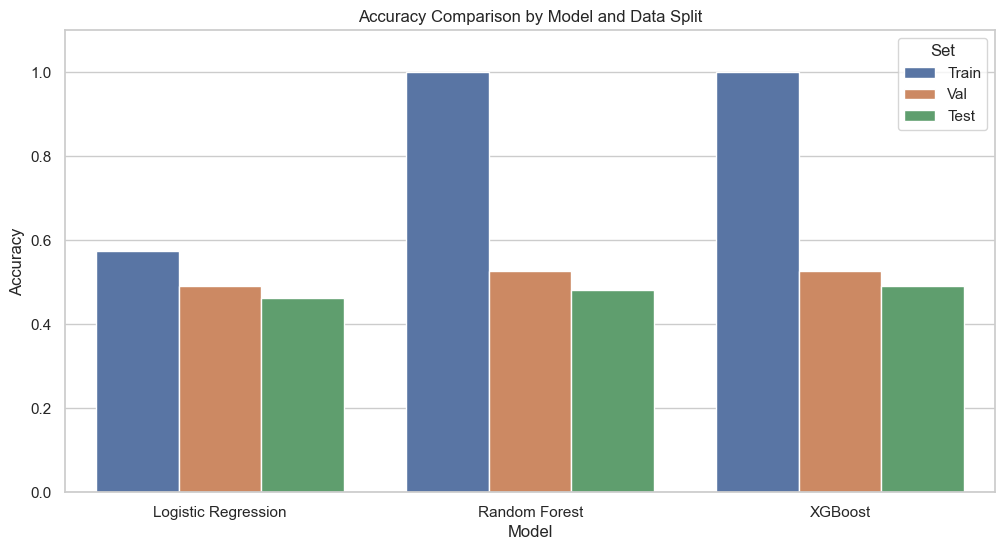

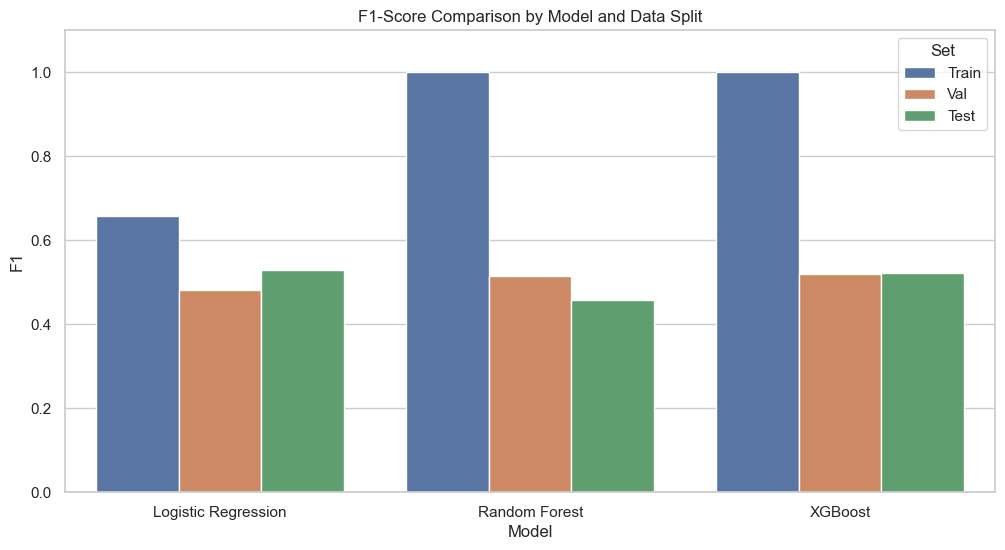

In [19]:
results_df = pd.DataFrame(all_results)

# Test Set 결과만 필터링하여 비교
test_comparison = results_df[results_df['Set'] == 'Test'].set_index('Model')
print("\n--- [Final Test Set Comparison] ---")
display(test_comparison)

# 시각화: Accuracy 비교
sns.barplot(data=results_df, x='Model', y='Accuracy', hue='Set')
plt.title("Accuracy Comparison by Model and Data Split")
plt.ylim(0, 1.1)
plt.show()

# 시각화: F1-Score 비교
sns.barplot(data=results_df, x='Model', y='F1', hue='Set')
plt.title("F1-Score Comparison by Model and Data Split")
plt.ylim(0, 1.1)
plt.show()